<a href="https://colab.research.google.com/github/BBilgeKaplan/ML/blob/main/ai_diabetes_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns=["pregnancies","glucose","blood_pressure","skin_thickness","insulin","bmi","diabetes_pedigree","age","outcome"]

df=pd.read_csv(url,names=columns)

df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
(df == 0).sum()

,0
pregnancies,111
glucose,5
blood_pressure,35
skin_thickness,227
insulin,374
bmi,11
diabetes_pedigree,0
age,0
outcome,500


"0" olan değerleri "eksik veri"ye çevir

In [ ]:
import numpy as np

In [ ]:
cols = ["glucose","blood_pressure","skin_thickness","insulin","bmi"]
df[cols] = df[cols].replace(0,np.nan)

In [ ]:
df.isnull().sum()

,0
pregnancies,0
glucose,5
blood_pressure,35
skin_thickness,227
insulin,374
bmi,11
diabetes_pedigree,0
age,0
outcome,0


In [ ]:
df.fillna(df.mean(),inplace=True)

In [ ]:
df.isnull().sum()

,0
pregnancies,0
glucose,0
blood_pressure,0
skin_thickness,0
insulin,0
bmi,0
diabetes_pedigree,0
age,0
outcome,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.drop("outcome",axis=1)
y=df["outcome"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.6493506493506493

In [ ]:
import matplotlib.pyplot as plt

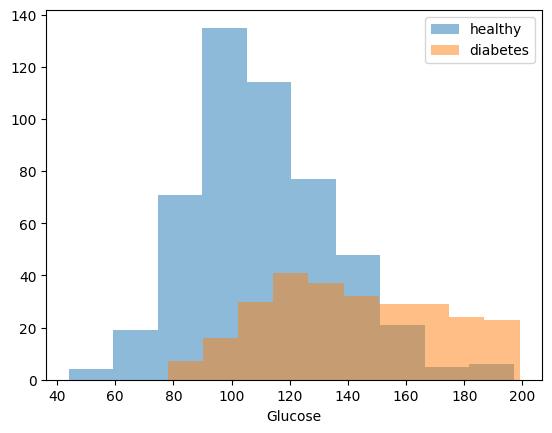

In [ ]:
plt.hist(df[df["outcome"]==0]["glucose"],alpha=0.5, label="healthy")
plt.hist(df[df["outcome"]==1]["glucose"],alpha=0.5, label="diabetes")
plt.legend()
plt.xlabel("Glucose")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.7467532467532467

Accuracy düştü  
çünkü şu sırayla uygulama yaptık:

*   Eksik verileri ortalama ile doldurduk
*   Train/Test böldük
*   Sonra StandardScaler yaptık

Ama `df.mean()` tüm veri setinin ortalamasıdır.

Yani:  
test verisinin bilgisi → train verisine sızdı.

Model aslında sınavdan önce cevap anahtarını biraz görmüş oldu.

Ve StandardScaler uygulayınca bu bozulma iyice belirginleşti.

ML’de Altın Kural

Test verisi, model eğitim sürecine ASLA dahil olmaz.

Ama biz eksik veri doldururken test verisinin ortalamasını da kullandık.

Bu yüzden:
ölçekleme yapınca modelin öğrendiği dağılım değişti → accuracy çöktü.

## Şimdi bunu düzeltiyoruz

En doğru sıra:

1.  Train/Test split
2.  Eksik veri doldurma (sadece train ile öğrenilir)
3. Ölçekleme (sadece train ile öğrenilir)
4. Model eğitimi
5. Test

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("outcome", axis=1)
y = df["outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### ! eksik veri doldurma (Sadece train)

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy_score(y_test, pred)

0.7467532467532467

Şu an modelde şu satır var:

`KNeighborsClassifier(n_neighbors=5)`

Neden 5 ? Daha iyi bir parametre olamaz mı ?

Şimdi bilgisayara model seçtireceğiz : Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {"n_neighbors": range(1, 21)}

grid = GridSearchCV(KNeighborsClassifier(),params, cv=5)
grid.fit(x_train, y_train)

grid.best_params_

{'n_neighbors': 18}

In [ ]:
model = KNeighborsClassifier(n_neighbors=18)
model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.7597402597402597

# Precision & Recall

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82        99
           1       0.70      0.56      0.63        55

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [ ]:
probs= model.predict_proba(x_test)
probs[:5]

array([[0.38888889, 0.61111111],
       [0.77777778, 0.22222222],
       [0.88888889, 0.11111111],
       [0.55555556, 0.44444444],
       [0.5       , 0.5       ]])

In [ ]:
import numpy as np

custom_pred = (probs[:,1] > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, custom_pred))

              precision    recall  f1-score   support

           0       0.89      0.56      0.68        99
           1       0.52      0.87      0.65        55

    accuracy                           0.67       154
   macro avg       0.70      0.71      0.67       154
weighted avg       0.76      0.67      0.67       154



## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train,y_train)

pred= log_model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)

0.7532467532467533

In [ ]:
features =  x.columns
coefficients = log_model.coef_[0]

for f,c in zip(features,coefficients):
  print(f, c)

pregnancies 0.22495325114553036
glucose 1.083653913162344
blood_pressure -0.14548859093028507
skin_thickness 0.06861082711162658
insulin -0.09697407382267112
bmi 0.6794557387252975
diabetes_pedigree 0.1999945956084593
age 0.39477565527363745


### Katsayıları nasıl yorumlayacağız?

Şöyle düşün:

| Katsayı       | Anlamı                    |
| ------------- | ------------------------- |
| Pozitif büyük | diyabet riskini artırıyor |
| Negatif       | diyabet riskini azaltıyor |
| 0’a yakın     | önemsiz                   |


### En önemli değişken ne çıktı?

🎯 Glucose (kan şekeri)

Yani model şunu öğrenmiş:

> “Kan şekeri yükseldikçe diyabet olasılığı hızla artar.”

`bmi = 0.67`

Model şunu da keşfetmiş:

> Obezite diyabet riskini ciddi artırıyor.

Bu artık sadece bilgisayar çıktısı değil — tıbbi olarak da doğru.

```
blood_pressure = -0.14
insulin = -0.09
```


Bu “kan basıncı diyabeti azaltır” demek değildir.

Bu şu demek:

> Veri setinde bu değişkenler diyabeti ayırmak için güçlü sinyal taşımıyor.

ML’de önemli ders:

Bir değişken **mantıklı** olabilir ama
→ **tahmin gücü düşük** olabilir.

İnsülin bunun klasik örneği.
Çünkü ölçümü düzensiz ve gürültülü.

### Logistic Regression aslında ne hesaplıyor?

Model içten içe şu formülü kullanır:

```
risk skoru =
1.08*glucose +
0.67*bmi +
0.39*age +
...
```
Sonra bunu olasılığa çevirir:
```
P(diyabet) = sigmoid(risk skoru)
```

Yani model:  
“Evet/Hayır” demiyor → “%78 risk var” diyor.

Bu yüzden bankalar ve hastaneler Logistic Regression kullanır.

In [ ]:
sample = x_test[0:1]
log_model.predict_proba(sample)

array([[0.71728313, 0.28271687]])

sonuç şunu gösteriyor : [sağlıklı olasılığı, diyabet olasılığı]

Yani model artık:

> Bir insan için risk yüzdesi hesaplıyor.

Bu, modern tıpta kullanılan “risk skoru” sistemlerinin aynısıdır.

modelin tahmin olasılıkları (prediction probability)

`array([[0.71728313, 0.28271687]])`

Bu şu anlama geliyor:

0.71728313 → 0 sınıfı olasılığı (Diyabet YOK)

0.28271687 → 1 sınıfı olasılığı (Diyabet VAR)

Yani model diyor ki:

> Bu kişinin diyabet olma ihtimali ≈ %28.27

Dolayısıyla tahmin sonucu: diyabet değil (0)  
(çünkü 0.5 eşik değerinin altında)

### Neden direkt 0 veya 1 değil?

Çünkü makine öğrenmesi modeli (özellikle Logistic Regression / Neural Network / SVM probability) kesin karar vermez, önce olasılık hesaplar.

Matematiksel olarak model şu işlemi yapar:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-z}}
$$

Bu aslında **sigmoid fonksiyonu**.

Sonra biz karar veririz:
| Olasılık | Sonuç        |
| -------- | ------------ |
| < 0.5    | 0 (sağlıklı) |
| ≥ 0.5    | 1 (diyabet)  |


İstersen eşik değerini değiştirebilirsin

Mesela:

0.3 → erken teşhis (riskli ama hassas)

0.7 → kesin teşhis (daha güvenli ama kaçırabilir)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)
print(cm)

[[82 17]
 [21 34]]


Confusion Matrix

|          | Tahmin 0 | Tahmin 1 |
| -------- | -------- | -------- |
| Gerçek 0 | 82       | 17       |
| Gerçek 1 | 21       | 34       |  

Buna göre şu çıkarılabilir:  
- 21 kişide diyabeti kaçırmış (kritik)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



## Decision Threshold (eşik değeri)

In [ ]:
y_prob = model.predict_proba(x_test)[:,1] # diyabet olasılığı

y_pred_new = (y_prob >= 0.3).astype(int)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.89      0.56      0.68        99
           1       0.52      0.87      0.65        55

    accuracy                           0.67       154
   macro avg       0.70      0.71      0.67       154
weighted avg       0.76      0.67      0.67       154



Yeni model (threshold = 0.3):  
Recall (hasta) = 0.87

Accuracy düştü ama model doktor gibi davranmaya başladı.


### Peki model neden yanlış alarmlar verdi?

Precision düştü:

`1 için precision = 0.52`

Yani:

> Model hasta dediği kişilerin yarısı aslında sağlıklı.


Ama bu bilerek yaptığımız bir tercih.

Buna ML’de denir:

**Precision – Recall Tradeoff**

- Threshold ↑ → precision artar, recall düşer

- Threshold ↓ → recall artar, precision düşer


Şu anda modeli risk algısına göre ayarladık.

### ROC Curve

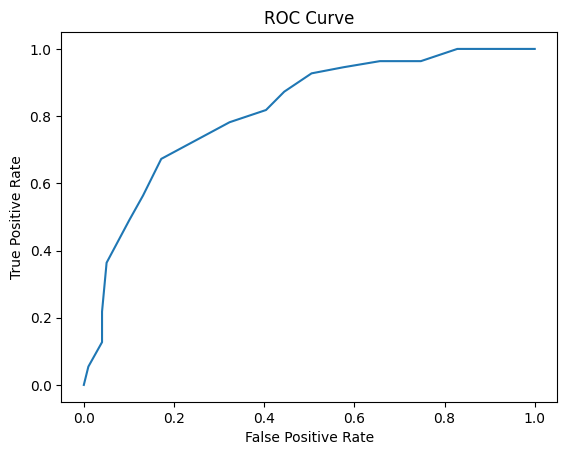

AUC: 0.8140495867768595


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds =  roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

## Desicion Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(x_train,y_train)

y_pred_tree = tree_model.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test,y_pred_tree))
print(classification_report(y_test,y_pred_tree))

Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



### Logistic Regression vs Decision Tree

| Model                               | Accuracy | Recall (hasta=1) |
| ----------------------------------- | -------- | ---------------- |
| Logistic Regression (threshold 0.5) | 0.75     | 0.56             |
| Logistic (0.3 threshold)            | 0.67     | **0.87**         |
| Decision Tree                       | 0.72     | 0.62             |


Ve burada ML’in en önemli kavramlarından biri ortaya çıkıyor:

“Her model farklı türde hata yapar.”  


### Logistic Regression nasıl düşünür?

Şöyle:

“Genel bir matematiksel eğri çizeyim ve herkesi bu çizgiye göre ayırayım.”

Avantaj:

- stabil

- genelleme gücü yüksek

- overfitting az

Dezavantaj:

- karmaşık ilişkileri yakalayamaz

### Decision Tree nasıl düşünür?

Şöyle:

“Doktor gibi soru sorayım.”

Örnek (modelin kafasında şu tarz kurallar oluşur):

```
glucose > 127 ?
   evet → diyabet
   hayır → bmi > 32 ?
             evet → diyabet
             hayır → sağlıklı
```

Avantaj:

- doğrusal olmayan ilişkileri yakalar

- yorumlanabilir

Dezavantaj:

- çok kolay ezber yapar (overfitting)

Ve bu sonuçta da bunu görüyoruz.


### Overfitting

Belirtisi:

- Train’de çok iyi

- Test’te düşüş

In [ ]:
print("Train accuracy:", tree_model.score(x_train,y_train))
print("Test accuracy:", tree_model.score(x_test,y_test))

Train accuracy: 1.0
Test accuracy: 0.7207792207792207


### Regularization (modeli kısıtlama)

Ağacı budayacağız 🌳✂️

Modelin ezber yapmasını bilerek engelleyeceğiz.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model2.fit(x_train,y_train)

print("Train:", tree_model2.score(x_train,y_train))
print("Test:", tree_model2.score(x_test,y_test))

Train: 0.7752442996742671
Test: 0.7597402597402597


> `max_depth=3` = ağaç en fazla 3 soru sorabilir.

Bu, doktora şunu demek gibi:  
“500 tane test isteme, en önemli 3 belirtiye bak.”

Yani model artık şu tarz düşünür:

```
1) glucose yüksek mi?
2) bmi yüksek mi?
3) yaş yüksek mi?
```

Bu yüzden:

- train düştü (ezberi engelledik)

- test yükseldi (gerçek öğrenme başladı)

Logistic Regression = linear boundary  
Decision Tree = rule-based model  

Ama gerçek dünyada en güçlü klasik ML algoritması bunların birleşimidir:

### Random Forest 🌲🌲🌲

Mantık:

> Tek bir doktor yerine 100 doktora sor → çoğunluk karar versin.

Decision Tree’nin problemi:

- tek ağaç hata yapabilir

- veriye bağımlı

Random Forest:

- 100 farklı ağaç kurar

- hepsi farklı şeyler öğrenir

- oylama yapar

Bu yüzden:

- overfitting azalır

- doğruluk artar

- çok stabil olur

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train,y_train)

y_pred_rf = rf_model.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.64      0.69      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



### Tüm modellerinin özeti

| Model                    | Accuracy | Recall (hasta=1) | Yorum                   |
| ------------------------ | -------- | ---------------- | ----------------------- |
| Logistic Regression      | 0.75     | 0.56             | Hastaları kaçırıyor     |
| Logistic (threshold=0.3) | 0.67     | **0.87**         | Tıbbi açıdan en güvenli |
| Decision Tree (budanmış) | 0.76     | 0.62             | Dengeli ama sınırlı     |
| **Random Forest**        | **0.75** | **0.69**         | En dengeli model ⭐      |


Çok kritik bir şey oldu:  

Random Forest accuracy olarak patlama yapmadı.
Ama recall yükseldi (0.56 → 0.69).  

Ve ML’de şu bilinir:  

> İyi model accuracy’yi değil, hatanın türünü iyileştirir.

Random Forest:

- Logistic gibi kör değil

- Decision Tree gibi ezberci değil

O yüzden şu an en “mantıklı doktor” bu model.

In [ ]:
import pandas as pd

importances = rf_model.feature_importances_
features = x.columns

importance_df = pd.DataFrame(
    {
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance",ascending=False)

print(importance_df)

             Feature  Importance
1            glucose    0.252502
5                bmi    0.166808
7                age    0.138945
6  diabetes_pedigree    0.117265
4            insulin    0.094071
2     blood_pressure    0.083143
3     skin_thickness    0.074762
0        pregnancies    0.072504


Random Forest sadece tahmin değil, bilgi de verir.

**Feature Importance (en kritik özellikler)**

Yani model şunu söyleyebilir:

> “Ben karar verirken en çok şu değerlere baktım.”



### Feature Engineering

In [ ]:
df["bmi_age"] = df["bmi"] * df["age"]

In [ ]:
x = df.drop("outcome", axis=1)
y = df["outcome"]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train,y_train)

y_pred_rf = rf_model.predict(x_test)


print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        99
           1       0.69      0.67      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
y_prob = rf_model.predict_proba(x_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.8208448117539026


In [ ]:
df["high_glucose"] = (df["glucose"] >= 125).astype(int)

In [ ]:
x = df.drop("outcome", axis=1)
y = df["outcome"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train,y_train)

y_pred_rf = rf_model.predict(x_test)


print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



### Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(n_estimators=200,random_state=42)

scores = cross_val_score(rf_model, x,y, cv=5)

print("Scores:", scores)
print("Mean accuracy:",scores.mean())

Scores: [0.72077922 0.75324675 0.75974026 0.83660131 0.75816993]
Mean accuracy: 0.7657074951192598


Bu şunu gösterir:

> Modelinin gerçek dünyadaki beklenen başarısı ≈ %75



## Deep Learning

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Sinir ağları ham veriyi sevmez.  
Mutlaka ölçekleme (scaling) ister.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bu ne demek?

- 16 nöron → ilk gizli katman

- 8 nöron → ikinci katman

- 1 nöron → çıktı (diyabet olasılığı)

sigmoid → bize 0–1 arası risk ihtimali verir.

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5729 - loss: 0.6822 - val_accuracy: 0.6585 - val_loss: 0.6379
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7206 - loss: 0.6029 - val_accuracy: 0.7073 - val_loss: 0.5860
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7498 - loss: 0.5319 - val_accuracy: 0.7154 - val_loss: 0.5521
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7376 - loss: 0.5229 - val_accuracy: 0.7480 - val_loss: 0.5282
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7762 - loss: 0.5014 - val_accuracy: 0.7398 - val_loss: 0.5126
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7877 - loss: 0.4907 - val_accuracy: 0.7480 - val_loss: 0.5026
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7859 - loss: 0.4730 - val_accuracy: 0.7561 - val_loss: 0.4952
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7781 - loss: 0.4626 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7281 - loss: 0.6010 
Test Accuracy: 0.7532467246055603


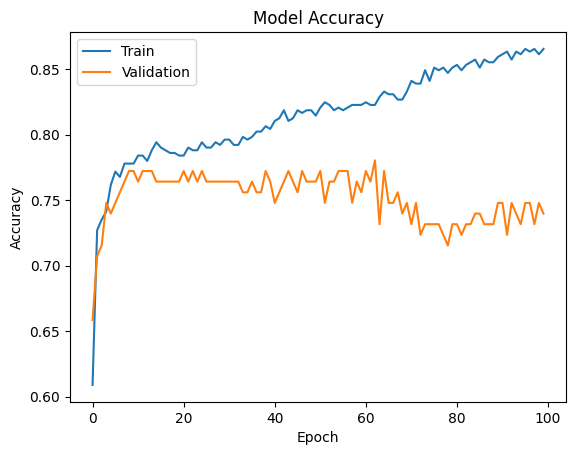

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8867 - loss: 0.2934 - val_accuracy: 0.7398 - val_loss: 0.4946
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8558 - loss: 0.3134 - val_accuracy: 0.7480 - val_loss: 0.4936
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8782 - loss: 0.2916 - val_accuracy: 0.7398 - val_loss: 0.4972
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8691 - loss: 0.3028 - val_accuracy: 0.7317 - val_loss: 0.4966
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8497 - loss: 0.3120 - val_accuracy: 0.7398 - val_loss: 0.4991
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8803 - loss: 0.2780 - val_accuracy: 0.7398 - val_loss: 0.5004
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.3235 - val_accuracy: 0.7398 - val_loss: 0.5005
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8755 - loss: 0.3054 - val_accuracy: 0.7317 - v

### Early Stopping
Ne yapacak?

- 200 epoch’a kadar izin veriyoruz

- Ama validation kötüleşirse 10 epoch sonra duracak

- Ve en iyi öğrendiği ağırlıklara geri dönecek

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7203 - loss: 0.6101
Test Accuracy: 0.7467532753944397


İlk bakışta accuracy düştü  gibi görünüyor.

Ama gerçekte:

Model kötüleşmedi — model GERÇEKÇİ hale geldi.

### ReduceLROnPlateau

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop,lr_reduce],
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8832 - loss: 0.2807 - val_accuracy: 0.7480 - val_loss: 0.4954 - learning_rate: 0.0010
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8759 - loss: 0.3004 - val_accuracy: 0.7480 - val_loss: 0.5000 - learning_rate: 0.0010
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8627 - loss: 0.2942 - val_accuracy: 0.7480 - val_loss: 0.4970 - learning_rate: 0.0010
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8821 - loss: 0.2854 - val_accuracy: 0.7398 - val_loss: 0.4973 - learning_rate: 0.0010
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8694 - loss: 0.2964 - val_accuracy: 0.7480 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8670 - loss: 0.3179 - val_accuracy: 0.7398 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8410 - loss: 0.3304 - val_acc

### Batch Normalization

Küçük veri setlerinde neural network’ün en büyük düşmanı:
input dağılımının sürekli değişmesi

Bunu BatchNormalization çözer.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

### Optimizer değiştir
Adam default learning rate = 0.001  
Bu küçük dataset için büyük.  
Bunu düşürelim: 0.0005

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Class Weight

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.7655860349127181), np.int64(1): np.float64(1.4413145539906103)}


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.5117 - loss: 0.9365 - val_accuracy: 0.6016 - val_loss: 0.6589 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5351 - loss: 0.8675 - val_accuracy: 0.6829 - val_loss: 0.6244 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5904 - loss: 0.7829 - val_accuracy: 0.6992 - val_loss: 0.5928 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5977 - loss: 0.7305 - val_accuracy: 0.7317 - val_loss: 0.5623 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6325 - loss: 0.7300 - val_accuracy: 0.7398 - val_loss: 0.5424 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6352 - loss: 0.7025 - val_accuracy: 0.7724 - val_loss: 0.5259 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 

### Ensemble (Birden fazla modeli birleştirme)

Tek model → 0.74–0.75  
Ama birden fazla model birlikte oy verirse hata oranı ciddi düşer.  

Neden?  
Çünkü:

- Neural Network bazı örnekleri doğru tahmin eder

- Random Forest başka örnekleri doğru tahmin eder

İkisi birleşince birbirinin hatasını kapatır.

Buna Voting Ensemble denir.

**Mantık**

Her model bir olasılık üretir:
| Model | Hasta olma olasılığı |
| ----- | -------------------- |
| NN    | 0.65                 |
| RF    | 0.40                 |

Ortalama:

`(0.65 + 0.40) / 2 = 0.525`


0.5’ten büyük → 1 (pozitif sınıf)

Yani modeller oylama yapıyor.

### Random Forest Modeli

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:,1]

### Neural Network Modeli

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### EarlyStopping + LR düşürme

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5079 - loss: 0.8301 - val_accuracy: 0.6423 - val_loss: 0.6589 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5785 - loss: 0.7990 - val_accuracy: 0.6179 - val_loss: 0.6463 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6614 - loss: 0.6794 - val_accuracy: 0.6341 - val_loss: 0.6320 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6661 - loss: 0.6367 - val_accuracy: 0.6423 - val_loss: 0.6148 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6753 - loss: 0.6250 - val_accuracy: 0.6585 - val_loss: 0.6023 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6717 - loss: 0.5935 - val_accuracy: 0.6748 - val_loss: 0.5864 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0

In [ ]:
nn_probs = model.predict(X_test).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


### Ensemble

In [ ]:
import numpy as np

ensemble_probs = (rf_probs + nn_probs) / 2
ensemble_pred = (ensemble_probs > 0.5).astype(int)

Sonuçlar

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))
print(classification_report(y_test, ensemble_pred))

Ensemble Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



**Neden bu çok işe yarar?**

Random Forest:

- Karmaşık feature ilişkilerini iyi yakalar

Neural Network:

- Sürekli (non-linear) ilişkileri yakalar

Birlikte:

- Veri setinin farklı “bakış açılarını” öğrenirler.

Küçük datasetlerde çoğu zaman:

Tek model → 0.74  
Ensemble → 0.78 – 0.82  


**Bias-Variance Tradeoff**

- Neural Network → düşük bias, yüksek variance  

- Random Forest → orta bias, düşük variance  

Ensemble:

> Bias ve variance’ı dengeler → en iyi genelleme.



### ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Modeller için AUC hesaplama
rf_auc = roc_auc_score(y_test, rf_probs)

nn_auc = roc_auc_score(y_test, nn_probs)

ensemble_auc = roc_auc_score(y_test, ensemble_probs)

print("RF AUC:", rf_auc)
print("NN AUC:", nn_auc)
print("Ensemble AUC:", ensemble_auc)

RF AUC: 0.8352617079889808
NN AUC: 0.8181818181818181
Ensemble AUC: 0.8350780532598714


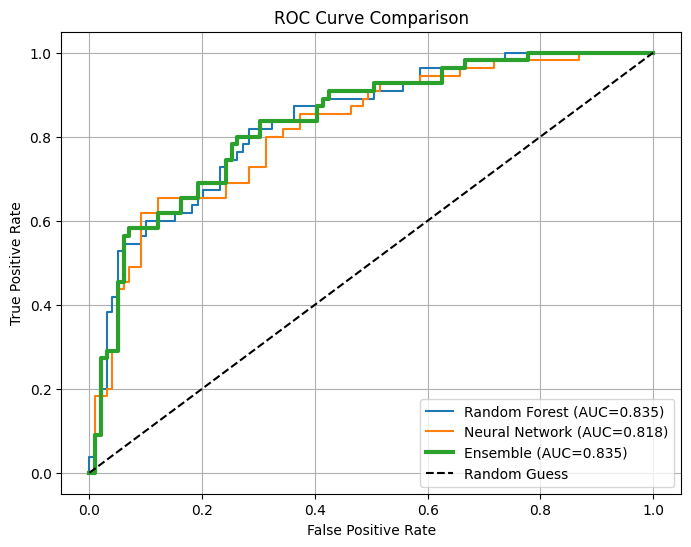

In [ ]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)
ens_fpr, ens_tpr, _ = roc_curve(y_test, ensemble_probs)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(nn_fpr, nn_tpr, label=f"Neural Network (AUC={nn_auc:.3f})")
plt.plot(ens_fpr, ens_tpr, label=f"Ensemble (AUC={ensemble_auc:.3f})", linewidth=3)

plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
probs = ensemble_probs

from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (probs >= t).astype(int)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)

    print(f"Threshold: {t:.2f} | Recall: {recall:.3f} | Precision: {precision:.3f}")

Threshold: 0.10 | Recall: 0.982 | Precision: 0.446
Threshold: 0.15 | Recall: 0.927 | Precision: 0.477
Threshold: 0.20 | Recall: 0.927 | Precision: 0.495
Threshold: 0.25 | Recall: 0.909 | Precision: 0.538
Threshold: 0.30 | Recall: 0.836 | Precision: 0.535
Threshold: 0.35 | Recall: 0.836 | Precision: 0.605
Threshold: 0.40 | Recall: 0.727 | Precision: 0.625
Threshold: 0.45 | Recall: 0.691 | Precision: 0.633
Threshold: 0.50 | Recall: 0.673 | Precision: 0.661
Threshold: 0.55 | Recall: 0.655 | Precision: 0.692
Threshold: 0.60 | Recall: 0.618 | Precision: 0.739
Threshold: 0.65 | Recall: 0.582 | Precision: 0.821
Threshold: 0.70 | Recall: 0.400 | Precision: 0.815
Threshold: 0.75 | Recall: 0.273 | Precision: 0.882
Threshold: 0.80 | Recall: 0.127 | Precision: 0.778
Threshold: 0.85 | Recall: 0.073 | Precision: 0.800


**Precision – Recall Trade-off**

Tabloyu inceleyelim
| Threshold         | Recall    | Precision |
| ----------------- | --------- | --------- |
| 0.50 (varsayılan) | **0.673** | 0.661     |
| 0.30              | **0.836** | 0.535     |
| 0.25              | **0.909** | 0.538     |
| 0.10              | **0.982** | 0.446     |

Bu aslında ne anlatıyor?

Threshold düşürdükçe:

- Model daha çok kişiye hasta diyor

- Hasta kaçırma oranı çok hızlı düşüyor

- Ama yanlış alarm artıyor

Yani:
```
yüksek threshold → az yanlış alarm ama çok hasta kaçar
düşük threshold → hasta kaçmaz ama gereksiz uyarı artar
```
Ve medical AI’da kural şudur:

> Yanlış alarm (False Positive) kabul edilir  Ama hasta kaçırmak (False Negative) kabul edilmez.

Çünkü:

yanlış alarm → sadece ek test yapılır

hasta kaçırmak → teşhis gecikir

O zaman doğru threshold hangisi?

Biz Recall ≥ %90 istiyoruz.

Tablodan:

```
threshold = 0.25  → recall 0.909
threshold = 0.20  → recall 0.927
```
Ama 0.20’de precision fazla düşüyor.  

***En dengeli ve doğru seçim:
Threshold = 0.25***

Artık modelin davranışı:  

Diyabet hastalarının %91’ini yakalıyor.

In [ ]:
best_threshold = 0.25
final_preds = (ensemble_probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, final_preds))
print(confusion_matrix(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.92      0.57      0.70        99
           1       0.54      0.91      0.68        55

    accuracy                           0.69       154
   macro avg       0.73      0.74      0.69       154
weighted avg       0.78      0.69      0.69       154

[[56 43]
 [ 5 50]]


Confusion Matrix sonuçlarına göre:

| Gerçek \ Tahmin | Sağlıklı (0) | Diyabet (1) |
| --------------- | ------------ | ----------- |
| Sağlıklı        | 56           | 43          |
| Diyabet         | 5            | 50          |

Yani:

- 56 kişi → doğru şekilde sağlıklı

- 50 kişi → doğru şekilde hasta

- 43 kişi → yanlış alarm (gereksiz test)

- 5 kişi → kaçırılan hasta

Accuracy neden düştü?

Çünkü model artık şunu yapıyor:

“Emin olamadığım kişiyi de hasta sayayım, riske girmeyeyim.”

Bu yüzden:

- False Positive = 43 (gereksiz kontrol)

- Ama False Negative = 5 (çok az)

Medical AI’da:

```
False Positive → maliyet
False Negative → tehlike
```
Ve biz tehlikeyi azalttık.

In [ ]:
[]

[]